# Electronics Store Sales Data Analysis 

In [1]:
# import libiaries 

import os
import pandas as pd
import matplotlib.pyplot as plt

### Merging the data from each month into one file

In [2]:
path = r"C:\Users\LENOVO\Desktop\Folder1"
files = [file for file in os.listdir(path) if not file.startswith('.')] # Ignore hidden files

In [3]:
all_months_data = pd.DataFrame()

for file in files: 
    current_data = pd.read_csv(path+"/"+file)
    all_months_data = pd.concat([all_months_data, current_data])

all_months_data.to_csv("all_data.csv", index=False)

### Reading in updated dataframe

In [5]:
all_data = pd.read_csv("all_data.csv")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [6]:
all_data.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,186305,186305,186305,186305,186305,186305
unique,178438,20,10,24,142396,140788
top,Order ID,USB-C Charging Cable,1,11.95,Order Date,Purchase Address
freq,355,21903,168552,21903,355,355


In [7]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Order ID          186305 non-null  str  
 1   Product           186305 non-null  str  
 2   Quantity Ordered  186305 non-null  str  
 3   Price Each        186305 non-null  str  
 4   Order Date        186305 non-null  str  
 5   Purchase Address  186305 non-null  str  
dtypes: str(6)
memory usage: 8.6 MB


In [8]:
# finding and dropping rows with NaN 

# finding 

nan_df = all_data[all_data.isna().any(axis=1)]
nan_df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1,NaN,NaN,NaN,NaN,NaN,NaN
356,NaN,NaN,NaN,NaN,NaN,NaN
735,NaN,NaN,NaN,NaN,NaN,NaN
1433,NaN,NaN,NaN,NaN,NaN,NaN
1553,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# dropping rows with NaN

all_data = all_data.dropna(how="all")
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


In [10]:
# rechecking 

nan_df = all_data[all_data.isna().any(axis=1)]
display(nan_df.head())

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


### Converting the data type (Data Formatting)

In [11]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


In [12]:
all_data.info()

<class 'pandas.DataFrame'>
Index: 186305 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Order ID          186305 non-null  str  
 1   Product           186305 non-null  str  
 2   Quantity Ordered  186305 non-null  str  
 3   Price Each        186305 non-null  str  
 4   Order Date        186305 non-null  str  
 5   Purchase Address  186305 non-null  str  
dtypes: str(6)
memory usage: 9.9 MB


In [13]:
# formatting Date column

all_data["Order Date"] = pd.to_datetime(all_data["Order Date"], format="%m/%d/%y %H:%M")

ValueError: time data "Order Date" doesn't match format "%m/%d/%y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [13]:
converted_dates = pd.to_datetime(
    all_data["Order Date"],
    format="%m/%d/%y %H:%M",
    errors="coerce"
)

error_rows = all_data[converted_dates.isna()]

In [14]:
print(error_rows["Order Date"].unique())

['Order Date']


In [15]:
print(error_rows.head(20))

       Order ID  Product  Quantity Ordered  Price Each  Order Date  \
519    Order ID  Product  Quantity Ordered  Price Each  Order Date   
1149   Order ID  Product  Quantity Ordered  Price Each  Order Date   
1155   Order ID  Product  Quantity Ordered  Price Each  Order Date   
2878   Order ID  Product  Quantity Ordered  Price Each  Order Date   
2893   Order ID  Product  Quantity Ordered  Price Each  Order Date   
3036   Order ID  Product  Quantity Ordered  Price Each  Order Date   
3209   Order ID  Product  Quantity Ordered  Price Each  Order Date   
3618   Order ID  Product  Quantity Ordered  Price Each  Order Date   
4138   Order ID  Product  Quantity Ordered  Price Each  Order Date   
4645   Order ID  Product  Quantity Ordered  Price Each  Order Date   
4794   Order ID  Product  Quantity Ordered  Price Each  Order Date   
5303   Order ID  Product  Quantity Ordered  Price Each  Order Date   
6939   Order ID  Product  Quantity Ordered  Price Each  Order Date   
7497   Order ID  Pro

In [16]:
# Convert 'Order Date' to datetime, coercing errors to NaT
all_data["Order Date"] = pd.to_datetime(all_data["Order Date"], errors='coerce', format="%m/%d/%y %H:%M")

# Drop rows where 'Order Date' could not be converted
all_data = all_data.dropna(subset=["Order Date"])

In [17]:
#convert 'Order ID' to an integer
all_data["Order ID"] = all_data["Order ID"].astype(int)

In [18]:
#Convert 'Quantity Ordered' to integer
all_data["Quantity Ordered"] = all_data["Quantity Ordered"].astype(int)

# Convert 'Price Each' to float
all_data["Price Each"] = all_data["Price Each"].astype(float)

In [19]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  int64         
 1   Product           185950 non-null  object        
 2   Quantity Ordered  185950 non-null  int64         
 3   Price Each        185950 non-null  float64       
 4   Order Date        185950 non-null  datetime64[ns]
 5   Purchase Address  185950 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 9.9+ MB


## EDA (Exploratory Data Analysis)

### Adding required columns for data analysis 

In [17]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001"


In [19]:
all_data["Order Date"].dt.month

0         4
2         4
3         4
4         4
5         4
         ..
186845    9
186846    9
186847    9
186848    9
186849    9
Name: Order Date, Length: 185950, dtype: int32

In [20]:
# adding a 'month' column 

all_data["Month"] = all_data["Order Date"].dt.month

all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4
...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",9
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",9
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",9
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",9


In [25]:
# adding city columns  New York (NY)

def get_city(address): 
    return address.split(",")[1].strip()

def get_state(address):
    return address.split(",")[2].split(" ")[1]

all_data["City"] = all_data["Purchase Address"].apply(lambda x:f"{get_city(x)} ({get_state(x)})")

all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,Dallas (TX)
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,Boston (MA)
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles (CA)
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles (CA)
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,Los Angeles (CA)
...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",9,Los Angeles (CA)
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",9,San Francisco (CA)
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",9,San Francisco (CA)
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",9,San Francisco (CA)


### 1. Which month recorded the highest sales, and what was the total revenue by month?

In [26]:
# adding sales/revenue column 

all_data["Sales"] = all_data["Quantity Ordered"] * all_data["Price Each"]

all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,Dallas (TX),23.90
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,Boston (MA),99.99
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles (CA),600.00
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles (CA),11.99
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,Los Angeles (CA),11.99


In [27]:
# Group by "Month" and calculate total sales 

monthly_sales = all_data.groupby("Month")["Sales"].sum()
monthly_sales

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64

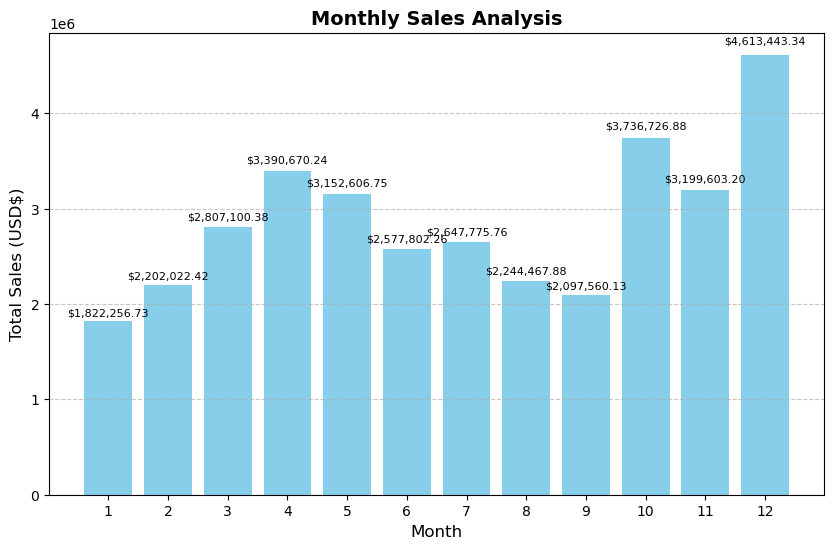

In [32]:
# advanced Plotting
plt.figure(figsize=(10, 6)) 
bars = plt.bar(monthly_sales.index, monthly_sales, color="skyblue") 
plt.xticks(monthly_sales.index)  # Set x-axis ticks to get detail
plt.title("Monthly Sales Analysis", fontsize=14, fontweight="bold")  # Improve title styling
plt.ylabel("Total Sales (USD$)", fontsize=12)  # Improve label clarity
plt.xlabel("Month", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Add a light grid for readability

for bar in bars:
    height = bar.get_height()  # Get the height of the bar (sales amount)
    plt.text(bar.get_x() + bar.get_width() / 2, height * 1.02, f"${height:,.2f}",  # Label with some spacing
             ha="center", va="bottom", fontsize=8,color="black")
    
plt.show()

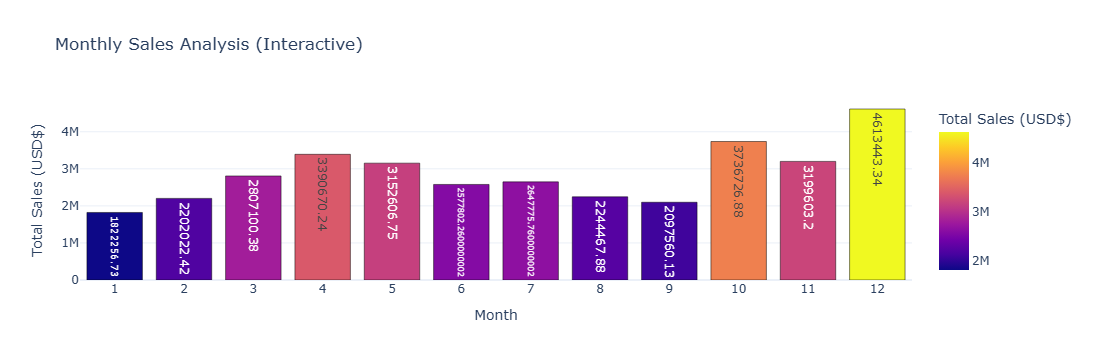

In [33]:
import plotly.express as px

# Convert Series to DataFrame
data = monthly_sales.reset_index()
data.columns = ['Month', 'Sales']

fig = px.bar(data, x='Month', y='Sales', text='Sales',
             color='Sales', template='plotly_white',
             title='Monthly Sales Analysis (Interactive)',
             labels={'Sales': 'Total Sales (USD$)', 'Month': 'Month'})

fig.update_traces(marker_line_color='black', hovertemplate='Month: %{x}<br>Sales: %{y} USD$')
fig.update_layout(xaxis=dict(dtick=1), hovermode='x')

fig.show()

### 2. Calculating Monthly Summary for Sales Quantity and Total Sales Amount 

In [34]:
# Group by 'Month' and sum the specified columns
monthly_summary = all_data.groupby("Month")[["Quantity Ordered", "Sales"]].sum()

monthly_summary

,Quantity Ordered,Sales
Month,,
1,10903,1822256.73
2,13449,2202022.42
3,17005,2807100.38
4,20558,3390670.24
5,18667,3152606.75
6,15253,2577802.26
7,16072,2647775.76
8,13448,2244467.88
9,13109,2097560.13


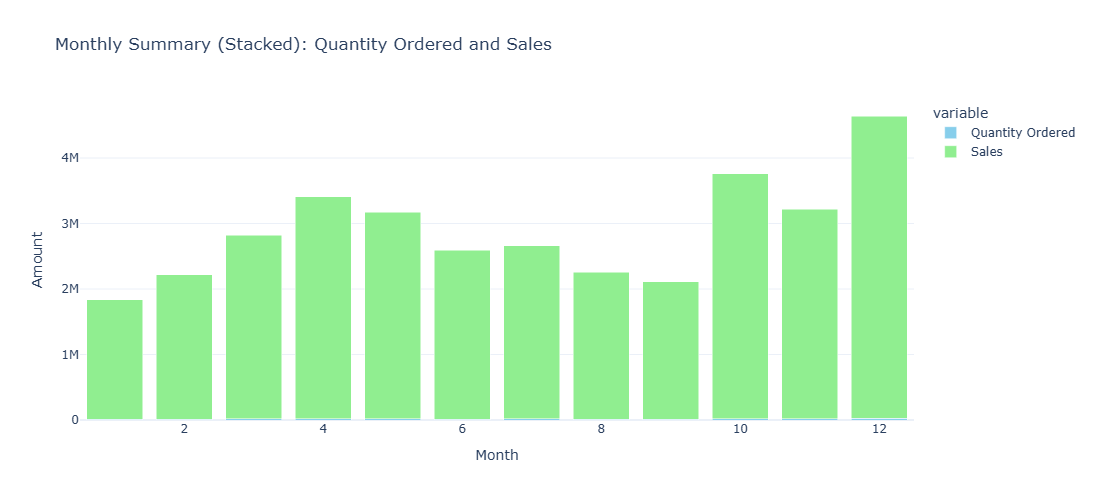

In [35]:
import plotly.express as px  # Import Plotly Express for easy chart creation

# Convert monthly_summary index into a column and rename it to "Month"
data2 = monthly_summary.reset_index().rename(columns={'index': 'Month'})

# Create a stacked bar chart with Plotly Express
fig = px.bar(
    data2,                                  # DataFrame to visualize
    x="Month",                              # X-axis → month
    y=["Quantity Ordered", "Sales"],  # Multiple columns to stack
    title="Monthly Summary (Stacked): Quantity Ordered and Sales",  # Chart title
    labels={"value": "Amount", "Month": "Month"},    # Axis/legend labels
    template="plotly_white",                # Clean white visual theme
    color_discrete_sequence=["skyblue", "lightgreen", "orange"]) # <-- CHANGE COLORS HERE

fig.update_layout(
    barmode="stack",   # Stack the bars on top of each other
    hovermode="x",     # Show hover info for all bars in the same x-position
    width=900,         # Chart width
    height=500)        # Chart height

fig.show() 

### 3. Which city sold the most product?

### Option 1

In [36]:
city = all_data.groupby("City")[["Product", "Quantity Ordered", "Sales"]].sum()
city

,Product,Quantity Ordered,Sales
City,,,
Atlanta (GA),USB-C Charging CableLightning Charging CableBo...,16602,2795498.58
Austin (TX),Apple Airpods HeadphonesApple Airpods Headphon...,11153,1819581.75
Boston (MA),Bose SoundSport HeadphonesWired HeadphonesAppl...,22528,3661642.01
Dallas (TX),USB-C Charging Cable27in 4K Gaming MonitorAA B...,16730,2767975.40
Los Angeles (CA),Google PhoneWired HeadphonesWired HeadphonesGo...,33289,5452570.80
New York City (NY),Apple Airpods HeadphonesAAA Batteries (4-pack)...,27932,4664317.43
Portland (ME),AAA Batteries (4-pack)Flatscreen TVWired Headp...,2750,449758.27
Portland (OR),AAA Batteries (4-pack)Lightning Charging Cable...,11303,1870732.34
San Francisco (CA),USB-C Charging CableMacbook Pro LaptopUSB-C Ch...,50239,8262203.91


In [37]:
all_data.groupby("City")["Sales"].sum()

City
Atlanta (GA)          2795498.58
Austin (TX)           1819581.75
Boston (MA)           3661642.01
Dallas (TX)           2767975.40
Los Angeles (CA)      5452570.80
New York City (NY)    4664317.43
Portland (ME)          449758.27
Portland (OR)         1870732.34
San Francisco (CA)    8262203.91
Seattle (WA)          2747755.48
Name: Sales, dtype: float64

In [38]:
city_sales = all_data.groupby("City")["Sales"].sum()

In [40]:
city_sales.sort_values(ascending=False)

City
San Francisco (CA)    8262203.91
Los Angeles (CA)      5452570.80
New York City (NY)    4664317.43
Boston (MA)           3661642.01
Atlanta (GA)          2795498.58
Dallas (TX)           2767975.40
Seattle (WA)          2747755.48
Portland (OR)         1870732.34
Austin (TX)           1819581.75
Portland (ME)          449758.27
Name: Sales, dtype: float64

In [41]:
city_sales = city_sales.sort_values(ascending=False)

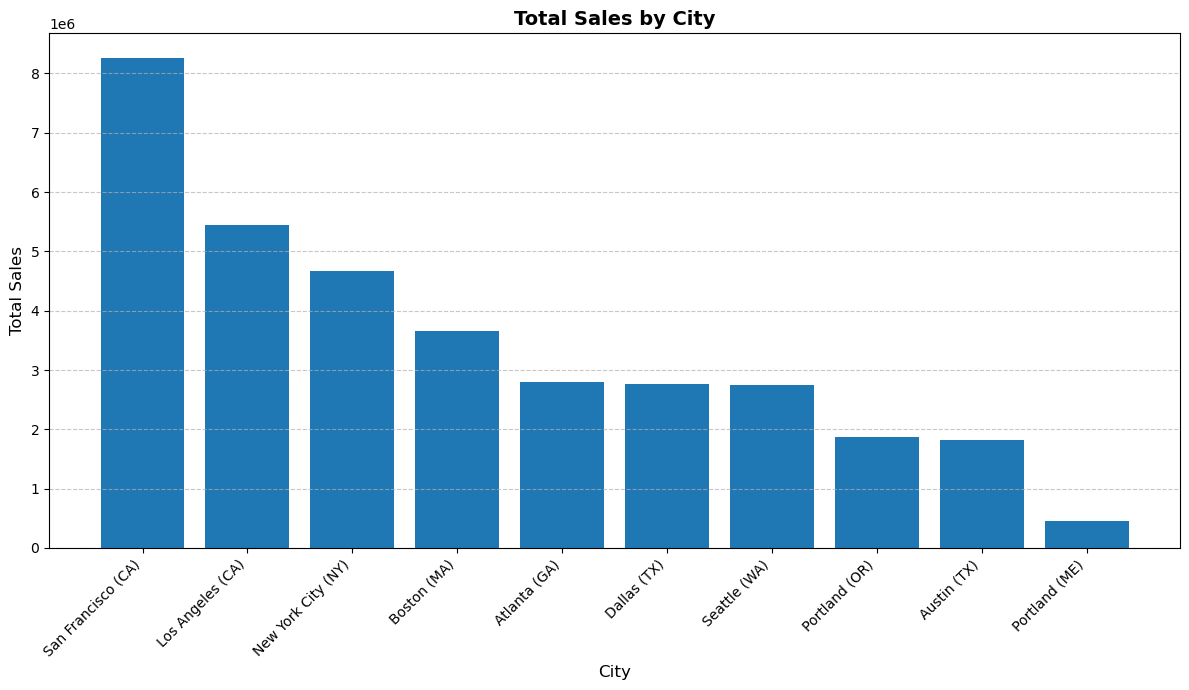

In [42]:
plt.figure(figsize=(12, 7))
plt.bar(city_sales.index, city_sales)
plt.title("Total Sales by City", fontsize=14, fontweight="bold")
plt.xlabel("City", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45, ha="right")  # Improve readability
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Option 2

In [43]:
all_data.groupby("City")["Sales"].sum().reset_index()

,City,Sales
0,Atlanta (GA),2795498.58
1,Austin (TX),1819581.75
2,Boston (MA),3661642.01
3,Dallas (TX),2767975.40
4,Los Angeles (CA),5452570.80
5,New York City (NY),4664317.43
6,Portland (ME),449758.27
7,Portland (OR),1870732.34
8,San Francisco (CA),8262203.91
9,Seattle (WA),2747755.48


In [44]:
city_summary = all_data.groupby("City")["Sales"].sum().reset_index()

In [45]:
city_summary["Sales_Pct"] = ((city_summary["Sales"] / city_summary["Sales"].sum()) * 100).round(1)

In [46]:
city_summary

,City,Sales,Sales_Pct
0,Atlanta (GA),2795498.58,8.1
1,Austin (TX),1819581.75,5.3
2,Boston (MA),3661642.01,10.6
3,Dallas (TX),2767975.40,8.0
4,Los Angeles (CA),5452570.80,15.8
5,New York City (NY),4664317.43,13.5
6,Portland (ME),449758.27,1.3
7,Portland (OR),1870732.34,5.4
8,San Francisco (CA),8262203.91,24.0
9,Seattle (WA),2747755.48,8.0


In [47]:
city_summary = city_summary.sort_values("Sales", ascending=False)
city_summary

,City,Sales,Sales_Pct
8,San Francisco (CA),8262203.91,24.0
4,Los Angeles (CA),5452570.80,15.8
5,New York City (NY),4664317.43,13.5
2,Boston (MA),3661642.01,10.6
0,Atlanta (GA),2795498.58,8.1
3,Dallas (TX),2767975.40,8.0
9,Seattle (WA),2747755.48,8.0
7,Portland (OR),1870732.34,5.4
1,Austin (TX),1819581.75,5.3
6,Portland (ME),449758.27,1.3


In [ ]:
# Insight 
# San Francisco leads sales with a 24% contribution, followed by Los Angeles (15.8%) and New York City (13.5%). 
# Together, these three cities generate over half of total sales, highlighting a strong reliance on major metropolitan markets.

### 4. What time should we display advertisements to maximize likelihood of customers buying products?

In [48]:
# Extract Hour and Minute from Order Date
all_data['Hour'] = all_data['Order Date'].dt.hour
all_data['Minute'] = all_data['Order Date'].dt.minute
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales,Hour,Minute
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,Dallas (TX),23.90,8,46
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,Boston (MA),99.99,22,30
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles (CA),600.00,14,38
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles (CA),11.99,14,38
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,Los Angeles (CA),11.99,9,27


In [49]:
# Group by Hour to count orders
results = all_data.groupby('Hour')['Order ID'].count()
results

Hour
0      3910
1      2350
2      1243
3       831
4       854
5      1321
6      2482
7      4011
8      6256
9      8748
10    10944
11    12411
12    12587
13    12129
14    10984
15    10175
16    10384
17    10899
18    12280
19    12905
20    12228
21    10921
22     8822
23     6275
Name: Order ID, dtype: int64

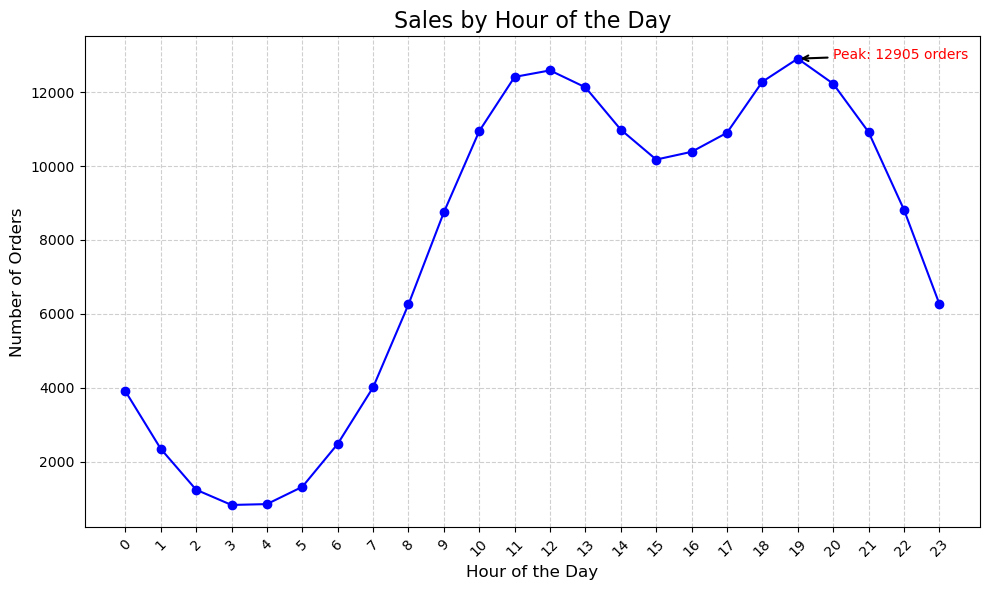

The peak hour for sales is 19:00 with 12905 orders.


In [50]:
# Plot sales by hour
plt.figure(figsize=(10, 6))
plt.plot(results.index, results.values, marker='o', linestyle='-', color='blue')
plt.xticks(results.index, rotation=45)
plt.title('Sales by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Highlight peak hours
peak_hour = results.idxmax()
peak_sales = results.max()
plt.annotate(f"Peak: {peak_sales} orders", 
             xy=(peak_hour, peak_sales), 
             xytext=(peak_hour + 1, peak_sales - 10),
             arrowprops=dict(arrowstyle="->", lw=1.5),
             fontsize=10, color='red')

plt.show()

# Output insight
print(f"The peak hour for sales is {peak_hour}:00 with {peak_sales} orders.")

# Highlight Peak Hour:
# results.idxmax(): Finds the hour with the maximum number of orders (peak hour).
# results.max(): Finds the value of the maximum orders (peak sales).
# plt.annotate: Adds an annotation pointing to the peak hour on the graph with an arrow.

### 5. What product sold the most?

In [54]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,City,Sales,Hour,Minute
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,Dallas (TX),23.90,8,46
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,Boston (MA),99.99,22,30
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles (CA),600.00,14,38
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,Los Angeles (CA),11.99,14,38
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,Los Angeles (CA),11.99,9,27


In [51]:
# Group by Product and calculate total quantity sold and mean price
product_group = all_data.groupby('Product')

In [52]:
product_group['Quantity Ordered'].sum()

Product
20in Monitor                   4129
27in 4K Gaming Monitor         6244
27in FHD Monitor               7550
34in Ultrawide Monitor         6199
AA Batteries (4-pack)         27635
AAA Batteries (4-pack)        31017
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
Flatscreen TV                  4819
Google Phone                   5532
LG Dryer                        646
LG Washing Machine              666
Lightning Charging Cable      23217
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
USB-C Charging Cable          23975
Vareebadd Phone                2068
Wired Headphones              20557
iPhone                         6849
Name: Quantity Ordered, dtype: int64

In [53]:
quantity_ordered = product_group['Quantity Ordered'].sum()

In [55]:
product_group['Price Each'].mean()

Product
20in Monitor                   109.99
27in 4K Gaming Monitor         389.99
27in FHD Monitor               149.99
34in Ultrawide Monitor         379.99
AA Batteries (4-pack)            3.84
AAA Batteries (4-pack)           2.99
Apple Airpods Headphones       150.00
Bose SoundSport Headphones      99.99
Flatscreen TV                  300.00
Google Phone                   600.00
LG Dryer                       600.00
LG Washing Machine             600.00
Lightning Charging Cable        14.95
Macbook Pro Laptop            1700.00
ThinkPad Laptop                999.99
USB-C Charging Cable            11.95
Vareebadd Phone                400.00
Wired Headphones                11.99
iPhone                         700.00
Name: Price Each, dtype: float64

In [56]:
prices = product_group['Price Each'].mean()

In [57]:
all_data['Product'].unique()

array(['USB-C Charging Cable', 'Bose SoundSport Headphones',
       'Google Phone', 'Wired Headphones', 'Macbook Pro Laptop',
       'Lightning Charging Cable', '27in 4K Gaming Monitor',
       'AA Batteries (4-pack)', 'Apple Airpods Headphones',
       'AAA Batteries (4-pack)', 'iPhone', 'Flatscreen TV',
       '27in FHD Monitor', '20in Monitor', 'LG Dryer', 'ThinkPad Laptop',
       'Vareebadd Phone', 'LG Washing Machine', '34in Ultrawide Monitor'],
      dtype=object)

In [58]:
products = all_data['Product'].unique()

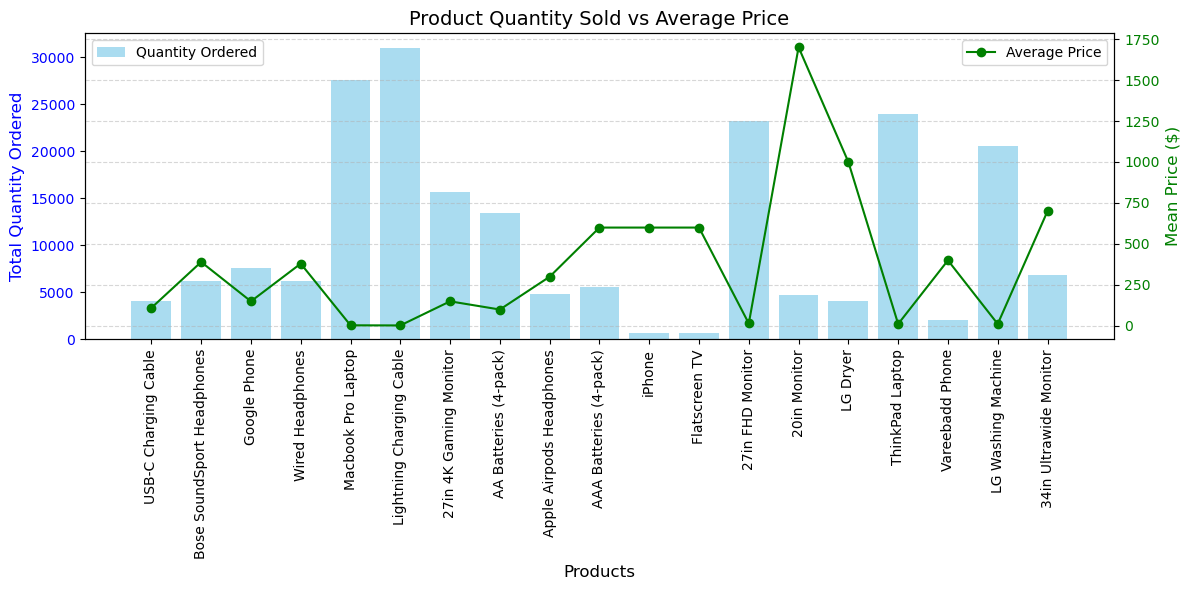

In [59]:
# Dual-axis chart for quantity sold and average price
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for quantity ordered (left axis)
ax1.bar(products, quantity_ordered, color='skyblue', alpha=0.7, label='Quantity Ordered')
ax1.set_ylabel('Total Quantity Ordered', color='blue', fontsize=12)
ax1.set_xlabel('Products', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(len(products)))
ax1.set_xticklabels(products, rotation='vertical', fontsize=10)
ax1.legend(loc='upper left')

# Line plot for prices (secondary y-axis)
ax2 = ax1.twinx()
ax2.plot(products, prices, color='green', marker='o', label='Average Price')
ax2.set_ylabel('Mean Price ($)', color='green', fontsize=12)
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

# Add grid and title
plt.title('Product Quantity Sold vs Average Price', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()